# 11 — Altitude Regression Atlas

Cross-crop altitude regression across all thematic RSU systems (RSU-67 through RSU-103).

Each system is a compound × crop × altitude transect drawn from a separate verified paper.
Reads directly from RSU JSON files — bypasses the typed schema because these RSUs store
compound-specific free-text metabolite values not captured in the FlavorBioactives dataclass.

**Two core mechanisms tested:**
- **UV-stress hypothesis:** phenolics, flavonoids, anthocyanins, glucosinolates, terpene precursors → increase with altitude
- **Temperature hypothesis:** lipid-soluble secondary metabolites synthesized via temperature-sensitive enzymatic pathways → decrease with altitude

**Output:** multi-panel figure + summary statistics table + mechanism-direction scatter

In [1]:
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from pathlib import Path

RSU_DIR = Path('../data/rsu')
OUT = Path('../data/metabolites')
OUT.mkdir(exist_ok=True)

## Helper functions

In [2]:
def rsu_path(rsu_id):
    """Find JSON path for a given RSU ID."""
    matches = list(RSU_DIR.glob(f'{rsu_id}_*.json'))
    if not matches:
        raise FileNotFoundError(f'No JSON found for {rsu_id}')
    return matches[0]


def get_altitude(rsu_id):
    """Return altitude_m from RSU coordinates."""
    d = json.load(open(rsu_path(rsu_id)))
    return d['coordinates'].get('altitude_m')


def _parse_first_number(s):
    """Extract numeric value from a metabolite free-text string.
    Priority: X ± Y → return X (mean)
              X-Y (range) → return midpoint
              first number in string
    Returns None if unparseable or if string is purely qualitative
    (starts with 'highest'/'lowest', contains 'NEEDS', or 'not detected').
    """
    s = str(s)
    sl = s.lower()
    # Purely qualitative strings: no leading number
    if 'NEEDS' in s or 'not detected' in sl or sl.startswith('highest') or sl.startswith('lowest'):
        return None
    # Mean ± SD
    m = re.search(r'(\d+\.?\d*)\s*[±]\s*(\d+\.?\d*)', s)
    if m:
        return float(m.group(1))
    # Explicit range X.XX-Y.YY (requires decimal points to avoid matching altitude ranges)
    m = re.search(r'(\d+\.\d+)-(\d+\.\d+)', s)
    if m:
        return (float(m.group(1)) + float(m.group(2))) / 2
    # ~X notation
    m = re.search(r'~(\d+\.?\d*)', s)
    if m:
        return float(m.group(1))
    # First bare number
    m = re.search(r'(\d+\.?\d*)', s)
    if m:
        return float(m.group(1))
    return None


def extract_value(rsu_id, category, field):
    """Extract numeric value for a given metabolite field from an RSU JSON.
    Searches all staple_foods entries and returns the first non-null parsed value.
    """
    d = json.load(open(rsu_path(rsu_id)))
    for sf in d['staple_foods']:
        val = sf['metabolite_profile'].get(category, {}).get(field)
        if val is None:
            continue
        parsed = _parse_first_number(val)
        if parsed is not None:
            return parsed
    return None


def load_system(system):
    """Load (altitude, value) pairs for a system definition.
    Returns sorted (altitudes, values) arrays with None-pairs dropped.
    """
    pairs = []
    for rsu_id in system['rsu_ids']:
        alt = get_altitude(rsu_id)
        val = extract_value(rsu_id, system['category'], system['field'])
        if alt is not None and val is not None:
            pairs.append((alt, val))
    pairs.sort(key=lambda x: x[0])
    if not pairs:
        return np.array([]), np.array([])
    alts, vals = zip(*pairs)
    return np.array(alts, dtype=float), np.array(vals, dtype=float)

## System registry

Each entry defines one compound × crop altitude transect.

- `mechanism`: `'UV'` (increases with altitude), `'temperature'` (decreases), `'complex'` (non-monotonic)
- `category` + `field`: keys into the JSON metabolite_profile dict
- `caveat`: any methodological caveat (variety confound, unit uncertainty, etc.)

In [3]:
SYSTEMS = [
    # ── UV-stress: compounds that increase with altitude ────────────────────────
    dict(
        label='Marjoram\nCarvacrol',
        crop='sweet marjoram', compound='carvacrol', units='% EO',
        mechanism='UV',
        rsu_ids=['RSU-90','RSU-91','RSU-92','RSU-93','RSU-94','RSU-95','RSU-96'],
        category='key_flavor_bioactives', field='carvacrol',
        source='Öner & Yeşil 2023 Sci Rep',
        caveat='Step-change at 1180m — ecotype transition'
    ),
    dict(
        label='Buckwheat\nRutin',
        crop='Tartary buckwheat', compound='rutin', units='mg/100g DW',
        mechanism='UV',
        rsu_ids=['RSU-84','RSU-83','RSU-82'],
        category='key_flavor_bioactives', field='rutin',
        source='Guo et al. 2011 Molecules',
        caveat=None
    ),
    dict(
        label='Highland Barley\nCGA',
        crop='highland barley (qingke)', compound='chlorogenic acid', units='µg/g DW',
        mechanism='UV',
        rsu_ids=['RSU-101','RSU-102','RSU-103'],
        category='key_flavor_bioactives', field='chlorogenic_acid',
        source='Yang et al. 2018 Molecules',
        caveat='Variety confound across sites'
    ),
    dict(
        label='Highland Barley\nRutin',
        crop='highland barley (qingke)', compound='rutin', units='µg/g DW',
        mechanism='UV',
        rsu_ids=['RSU-101','RSU-102','RSU-103'],
        category='key_flavor_bioactives', field='rutin',
        source='Yang et al. 2018 Molecules',
        caveat='Variety confound across sites'
    ),
    dict(
        label='Andean Blueberry\nTotal Phenolics',
        crop='Vaccinium floribundum', compound='total phenolics (TPC)', units='mg GAE/100g FW',
        mechanism='UV',
        rsu_ids=['RSU-89','RSU-88'],
        category='key_flavor_bioactives', field='total_phenolics_RC',
        source='Guevara-Terán et al. 2022 Molecules',
        caveat='n=2 only; ACY unit uncertain'
    ),
    dict(
        label='Andean Blueberry\nTotal Flavonoids',
        crop='Vaccinium floribundum', compound='total flavonoids (TFC)', units='mg Cateq/g FW',
        mechanism='UV',
        rsu_ids=['RSU-89','RSU-88'],
        category='key_flavor_bioactives', field='total_flavonoids_TFC',
        source='Guevara-Terán et al. 2022 Molecules',
        caveat='n=2 only'
    ),
    dict(
        label='Purple Corn\nAnthocyanins (kernel)',
        crop='purple corn (Canteño)', compound='total anthocyanins', units='mg C3G/100g DW',
        mechanism='UV',
        rsu_ids=['RSU-97','RSU-98'],
        category='key_flavor_bioactives', field='total_anthocyanins_kernel',
        source='Gálvez Ranilla et al. 2021 Metabolites',
        caveat='n=2 only; altitude ranges not point estimates'
    ),
    dict(
        label='Purple Corn\nTotal Phenolics (kernel)',
        crop='purple corn (Canteño)', compound='TPC kernel', units='mg GAE/100g DW',
        mechanism='UV',
        rsu_ids=['RSU-97','RSU-98'],
        category='key_flavor_bioactives', field='total_phenolics_kernel_TPC',
        source='Gálvez Ranilla et al. 2021 Metabolites',
        caveat='n=2 only'
    ),
    dict(
        label='Brassica\nSulforaphane',
        crop='cabbage (Brassica oleracea)', compound='sulforaphane', units='µg/mg DPE',
        mechanism='UV',
        rsu_ids=['RSU-100','RSU-99'],
        category='key_flavor_bioactives', field='sulforaphane_cabbage',
        source='Shukla et al. 2024 Sci Rep',
        caveat='n=2 only; µg/mg DPE units'
    ),
    # ── Temperature-driven: compounds that decrease with altitude ────────────────
    dict(
        label='Turmeric\nCurcumin',
        crop='turmeric', compound='curcumin', units='mg/g DW',
        mechanism='temperature',
        rsu_ids=['RSU-67','RSU-68','RSU-69'],
        category='key_flavor_bioactives', field='curcumin',
        source='Poudel et al. 2019 Molecules',
        caveat='Nepal only (excl. Korea — distinct cultivar)'
    ),
    dict(
        label='Marjoram\nLinalool',
        crop='sweet marjoram', compound='linalool', units='% EO',
        mechanism='temperature',
        rsu_ids=['RSU-90','RSU-91','RSU-92','RSU-93','RSU-94','RSU-95','RSU-96'],
        category='key_flavor_bioactives', field='linalool',
        source='Öner & Yeşil 2023 Sci Rep',
        caveat='Inverse of carvacrol; step-change at 1180m'
    ),
    # ── Complex / non-monotonic ─────────────────────────────────────────────────
    dict(
        label='Highland Barley\nTotal Phenolics',
        crop='highland barley (qingke)', compound='total phenolics (TPC)', units='mg GAE/100g DW',
        mechanism='complex',
        rsu_ids=['RSU-101','RSU-102','RSU-103'],
        category='key_flavor_bioactives', field='total_phenolic_content_TPC',
        source='Yang et al. 2018 Molecules',
        caveat='COUNTERINTUITIVE: TPC decreases; variety confound; catechin/gallic acid dominate'
    ),
    dict(
        label='Cocoa\nEpicatechin',
        crop='Theobroma cacao', compound='epicatechin', units='mg/100g DW',
        mechanism='complex',
        rsu_ids=['RSU-79','RSU-80','RSU-81'],
        category='key_flavor_bioactives', field='epicatechin',
        source='Mihai et al. 2022 Plants',
        caveat='Peaks at 400m; soil Mn/N dominates over altitude'
    ),
    dict(
        label='Ethiopian Coffee\nTotal CGA',
        crop='Coffea arabica', compound='total chlorogenic acids', units='mg/g DW',
        mechanism='complex',
        rsu_ids=['RSU-73','RSU-72','RSU-71','RSU-75','RSU-74'],
        category='key_flavor_bioactives', field='chlorogenic_acids_total',
        source='Mengesha et al. 2024 Front Nutr',
        caveat='No altitude gradient; variety × region dominates'
    ),
]

print(f'System registry: {len(SYSTEMS)} compound-crop systems defined')
for s in SYSTEMS:
    print(f"  [{s['mechanism']:11s}] {s['label'].replace(chr(10),' — ')} ({s['source'].split()[0]} {s['source'].split()[-1]})")

System registry: 14 compound-crop systems defined
  [UV         ] Marjoram — Carvacrol (Öner Rep)
  [UV         ] Buckwheat — Rutin (Guo Molecules)
  [UV         ] Highland Barley — CGA (Yang Molecules)
  [UV         ] Highland Barley — Rutin (Yang Molecules)
  [UV         ] Andean Blueberry — Total Phenolics (Guevara-Terán Molecules)
  [UV         ] Andean Blueberry — Total Flavonoids (Guevara-Terán Molecules)
  [UV         ] Purple Corn — Anthocyanins (kernel) (Gálvez Metabolites)
  [UV         ] Purple Corn — Total Phenolics (kernel) (Gálvez Metabolites)
  [UV         ] Brassica — Sulforaphane (Shukla Rep)
  [temperature] Turmeric — Curcumin (Poudel Molecules)
  [temperature] Marjoram — Linalool (Öner Rep)
  [complex    ] Highland Barley — Total Phenolics (Yang Molecules)
  [complex    ] Cocoa — Epicatechin (Mihai Plants)
  [complex    ] Ethiopian Coffee — Total CGA (Mengesha Nutr)


## Extract data for all systems

In [4]:
system_data = {}

for sys in SYSTEMS:
    alts, vals = load_system(sys)
    system_data[sys['label']] = (alts, vals)
    n = len(alts)
    if n >= 2:
        r, p = stats.pearsonr(alts, vals) if n >= 3 else (np.nan, np.nan)
        delta_pct = ((vals[-1] - vals[0]) / vals[0] * 100) if vals[0] != 0 else np.nan
        print(f"{sys['label'].replace(chr(10),' — '):40s}  n={n}  "
              f"alt={int(alts[0])}-{int(alts[-1])}m  "
              f"r={r:+.3f}  p={p:.3f}  Δ={delta_pct:+.0f}%")
    else:
        print(f"{sys['label'].replace(chr(10),' — '):40s}  n={n}  INSUFFICIENT DATA")

Marjoram — Carvacrol                      n=7  alt=766-1387m  r=+0.899  p=0.006  Δ=+624%
Buckwheat — Rutin                         n=3  alt=1422-2100m  r=+0.983  p=0.118  Δ=+19%
Highland Barley — CGA                     n=3  alt=2700-3658m  r=+0.928  p=0.243  Δ=+61%
Highland Barley — Rutin                   n=3  alt=2700-3658m  r=+0.914  p=0.266  Δ=+34%
Andean Blueberry — Total Phenolics        n=2  alt=2836-3641m  r=+nan  p=nan  Δ=+87%
Andean Blueberry — Total Flavonoids       n=2  alt=2836-3641m  r=+nan  p=nan  Δ=+86%
Purple Corn — Anthocyanins (kernel)       n=2  alt=2025-2828m  r=+nan  p=nan  Δ=+27%
Purple Corn — Total Phenolics (kernel)    n=2  alt=2025-2828m  r=+nan  p=nan  Δ=+45%
Brassica — Sulforaphane                   n=2  alt=321-3340m  r=+nan  p=nan  Δ=+115%
Turmeric — Curcumin                       n=3  alt=80-1530m  r=-0.984  p=0.115  Δ=-45%
Marjoram — Linalool                       n=7  alt=766-1387m  r=-0.863  p=0.012  Δ=-24%
Highland Barley — Total Phenolics         n=

## OLS regression function

In [5]:
def ols(alts, vals):
    """OLS regression. Returns dict with slope, intercept, r2, pval, se.
    Requires n>=3. Returns None if n<3.
    """
    if len(alts) < 3:
        return None
    res = stats.linregress(alts, vals)
    return dict(
        slope=res.slope,
        intercept=res.intercept,
        r2=res.rvalue**2,
        pval=res.pvalue,
        se=res.stderr,
        n=len(alts),
    )

## Multi-panel altitude regression atlas

Each panel = one compound × crop system. Color = mechanism:
- **Blue:** UV-stress (increases with altitude)
- **Red:** Temperature-driven (decreases with altitude)
- **Gray:** Complex / non-monotonic

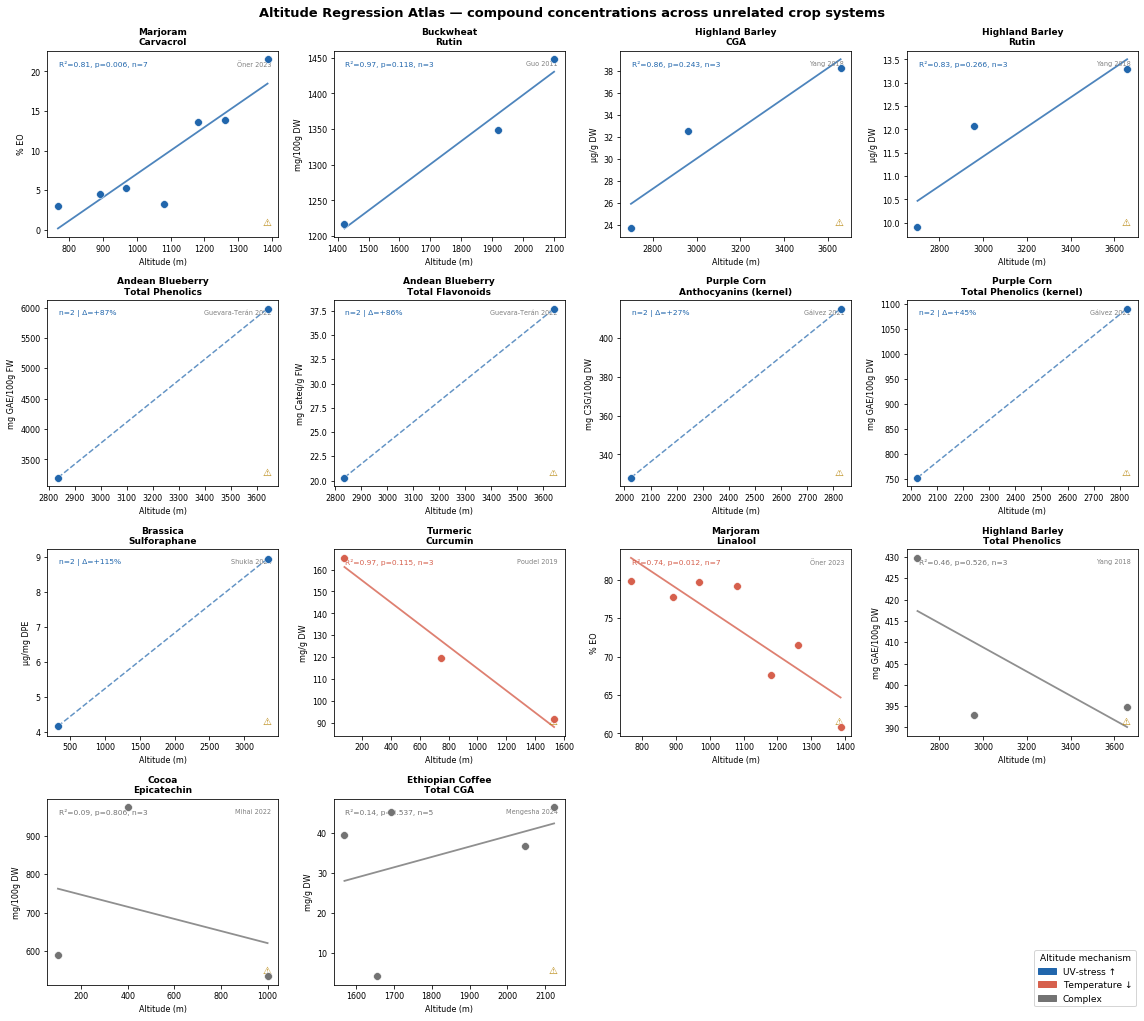

Saved: altitude_regression_atlas.png


In [6]:
MECH_COLOR = {'UV': '#2166ac', 'temperature': '#d6604d', 'complex': '#737373'}
MECH_LABEL = {'UV': 'UV-stress ↑', 'temperature': 'Temperature ↓', 'complex': 'Complex'}

NCOLS = 4
NROWS = (len(SYSTEMS) + NCOLS - 1) // NCOLS

fig, axes = plt.subplots(NROWS, NCOLS, figsize=(16, NROWS * 3.5))
axes_flat = axes.flatten()

for idx, sys in enumerate(SYSTEMS):
    ax = axes_flat[idx]
    alts, vals = system_data[sys['label']]
    color = MECH_COLOR[sys['mechanism']]
    n = len(alts)

    if n == 0:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes, color='gray')
        ax.set_title(sys['label'], fontsize=9, fontweight='bold')
        continue

    ax.scatter(alts, vals, color=color, s=60, zorder=4, edgecolors='white', linewidths=0.5)

    reg = ols(alts, vals)
    if reg is not None:
        x_fit = np.linspace(alts.min(), alts.max(), 100)
        y_fit = reg['slope'] * x_fit + reg['intercept']
        ax.plot(x_fit, y_fit, color=color, lw=1.8, alpha=0.8)
        p_str = f"p={reg['pval']:.3f}" if reg['pval'] >= 0.001 else 'p<0.001'
        stat_str = f"R²={reg['r2']:.2f}, {p_str}, n={reg['n']}"
        ax.text(0.05, 0.95, stat_str, transform=ax.transAxes,
                fontsize=7.5, va='top', color=color)
    elif n == 2:
        ax.plot(alts, vals, color=color, lw=1.5, alpha=0.7, ls='--')
        delta_pct = (vals[-1] - vals[0]) / vals[0] * 100
        ax.text(0.05, 0.95, f"n=2 | Δ={delta_pct:+.0f}%", transform=ax.transAxes,
                fontsize=7.5, va='top', color=color)

    # Caveat marker
    if sys.get('caveat'):
        ax.text(0.97, 0.05, '⚠', transform=ax.transAxes, fontsize=10,
                va='bottom', ha='right', color='#b8860b')

    ax.set_title(sys['label'], fontsize=9, fontweight='bold')
    ax.set_xlabel('Altitude (m)', fontsize=8)
    ax.set_ylabel(sys['units'], fontsize=8)
    ax.tick_params(labelsize=8)

    # Source footnote
    first_author = sys['source'].split()[0]
    year = [w for w in sys['source'].split() if w[:4].isdigit()]
    year_str = year[0][:4] if year else ''
    ax.text(0.97, 0.95, f"{first_author} {year_str}", transform=ax.transAxes,
            fontsize=6.5, va='top', ha='right', color='gray')

# Hide unused panels
for idx in range(len(SYSTEMS), len(axes_flat)):
    axes_flat[idx].set_visible(False)

# Legend
legend_patches = [mpatches.Patch(color=c, label=MECH_LABEL[m]) for m, c in MECH_COLOR.items()]
fig.legend(handles=legend_patches, loc='lower right', fontsize=9,
           title='Altitude mechanism', title_fontsize=9,
           bbox_to_anchor=(0.99, 0.01))

fig.suptitle(
    'Altitude Regression Atlas — compound concentrations across unrelated crop systems',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(OUT / 'altitude_regression_atlas.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: altitude_regression_atlas.png')

## Summary statistics table

In [7]:
rows = []
for sys in SYSTEMS:
    alts, vals = system_data[sys['label']]
    n = len(alts)
    label = sys['label'].replace('\n', ' — ')
    reg = ols(alts, vals) if n >= 3 else None

    if n < 2:
        rows.append(dict(system=label, n=n, alt_range='', slope_per_100m='', r2='', pval='',
                         direction='NO DATA', mechanism=sys['mechanism'], caveat=sys.get('caveat','')))
        continue

    delta_pct = (vals[-1] - vals[0]) / vals[0] * 100
    alt_range = f"{int(alts[0])}–{int(alts[-1])} m"
    direction = '↑ increase' if vals[-1] > vals[0] else '↓ decrease'

    if reg:
        slope_per_100m = f"{reg['slope']*100:+.4f}"
        r2_str = f"{reg['r2']:.3f}"
        pval_str = f"{reg['pval']:.4f}" if reg['pval'] >= 0.0001 else '<0.0001'
    else:
        slope_per_100m = 'n=2'
        r2_str = 'n=2'
        pval_str = f"Δ={delta_pct:+.0f}%"

    rows.append(dict(
        system=label,
        units=sys['units'],
        n=n,
        alt_range=alt_range,
        slope_per_100m=slope_per_100m,
        r2=r2_str,
        pval=pval_str,
        direction=direction,
        mechanism=MECH_LABEL[sys['mechanism']],
        source=sys['source'],
        caveat=sys.get('caveat') or ''
    ))

summary = pd.DataFrame(rows)
# Sort: UV first, then temperature, then complex
mech_order = {'UV': 0, 'temperature': 1, 'complex': 2}
summary['_mord'] = summary['mechanism'].map({'UV-stress ↑': 0, 'Temperature ↓': 1, 'Complex': 2})
summary = summary.sort_values('_mord').drop(columns='_mord')

pd.set_option('display.max_colwidth', 60)
pd.set_option('display.max_rows', 30)
display(summary[['system','units','n','alt_range','slope_per_100m','r2','pval','direction','mechanism']])

,system,units,n,alt_range,slope_per_100m,r2,pval,direction,mechanism
0,Marjoram — Carvacrol,% EO,7,766–1387 m,+2.9425,0.808,0.0059,↑ increase,UV-stress ↑
1,Buckwheat — Rutin,mg/100g DW,3,1422–2100 m,+32.4197,0.966,0.1178,↑ increase,UV-stress ↑
2,Highland Barley — CGA,µg/g DW,3,2700–3658 m,+1.3717,0.862,0.2426,↑ increase,UV-stress ↑
3,Highland Barley — Rutin,µg/g DW,3,2700–3658 m,+0.3167,0.835,0.2664,↑ increase,UV-stress ↑
4,Andean Blueberry — Total Phenolics,mg GAE/100g FW,2,2836–3641 m,n=2,n=2,Δ=+87%,↑ increase,UV-stress ↑
5,Andean Blueberry — Total Flavonoids,mg Cateq/g FW,2,2836–3641 m,n=2,n=2,Δ=+86%,↑ increase,UV-stress ↑
6,Purple Corn — Anthocyanins (kernel),mg C3G/100g DW,2,2025–2828 m,n=2,n=2,Δ=+27%,↑ increase,UV-stress ↑
7,Purple Corn — Total Phenolics (kernel),mg GAE/100g DW,2,2025–2828 m,n=2,n=2,Δ=+45%,↑ increase,UV-stress ↑
8,Brassica — Sulforaphane,µg/mg DPE,2,321–3340 m,n=2,n=2,Δ=+115%,↑ increase,UV-stress ↑
9,Turmeric — Curcumin,mg/g DW,3,80–1530 m,-5.0472,0.968,0.1150,↓ decrease,Temperature ↓


In [8]:
summary.to_csv(OUT / 'altitude_regression_summary.csv', index=False)
print('Saved: altitude_regression_summary.csv')
print()
print('=== Caveats ===')
for _, row in summary.iterrows():
    if row['caveat']:
        print(f"  {row['system']}: {row['caveat']}")

Saved: altitude_regression_summary.csv

=== Caveats ===
  Marjoram — Carvacrol: Step-change at 1180m — ecotype transition
  Highland Barley — CGA: Variety confound across sites
  Highland Barley — Rutin: Variety confound across sites
  Andean Blueberry — Total Phenolics: n=2 only; ACY unit uncertain
  Andean Blueberry — Total Flavonoids: n=2 only
  Purple Corn — Anthocyanins (kernel): n=2 only; altitude ranges not point estimates
  Purple Corn — Total Phenolics (kernel): n=2 only
  Brassica — Sulforaphane: n=2 only; µg/mg DPE units
  Turmeric — Curcumin: Nepal only (excl. Korea — distinct cultivar)
  Marjoram — Linalool: Inverse of carvacrol; step-change at 1180m
  Highland Barley — Total Phenolics: COUNTERINTUITIVE: TPC decreases; variety confound; catechin/gallic acid dominate
  Cocoa — Epicatechin: Peaks at 400m; soil Mn/N dominates over altitude
  Ethiopian Coffee — Total CGA: No altitude gradient; variety × region dominates


## Slope-direction summary: standardized effect sizes

For systems with n≥3 OLS, plot standardized slope (per 100m, z-scored within compound units)
against altitude range to see which systems have the strongest altitude signal.

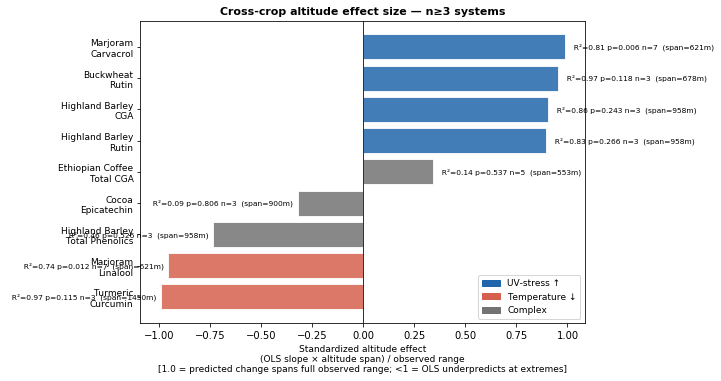

Saved: altitude_slope_summary.png


In [9]:
# Standardized effect size: OLS slope × altitude_span / observed_range
# = "fraction of observed range explained by full altitude span" — unit-free, comparable across systems.
effect_rows = []
for sys in SYSTEMS:
    alts, vals = system_data[sys['label']]
    n = len(alts)
    if n < 3:
        continue
    reg = ols(alts, vals)
    if reg is None:
        continue
    obs_range = vals.max() - vals.min()
    if obs_range == 0:
        continue
    alt_span = alts.max() - alts.min()
    # Signed effect: predicted change over full transect / observed range
    effect = reg['slope'] * alt_span / obs_range
    effect_rows.append(dict(
        label=sys['label'],
        effect=effect,
        r2=reg['r2'],
        pval=reg['pval'],
        mechanism=sys['mechanism'],
        n=n,
        alt_span=int(alt_span),
        units=sys['units'],
    ))

effect_df = pd.DataFrame(effect_rows).sort_values('effect')

fig, ax = plt.subplots(figsize=(10, max(4, len(effect_df) * 0.6)))
colors = [MECH_COLOR[row['mechanism']] for _, row in effect_df.iterrows()]
ax.barh(range(len(effect_df)), effect_df['effect'], color=colors, alpha=0.85, edgecolor='white')
ax.set_yticks(range(len(effect_df)))
ax.set_yticklabels([r['label'] for _, r in effect_df.iterrows()], fontsize=9)

for i, (_, row) in enumerate(effect_df.iterrows()):
    x = row['effect']
    p_str = f"p={row['pval']:.3f}" if row['pval'] >= 0.001 else 'p<0.001'
    label = f"  R\u00b2={row['r2']:.2f} {p_str} n={row['n']}  (span={row['alt_span']}m)"
    offset = 0.02 if x >= 0 else -0.02
    ha = 'left' if x >= 0 else 'right'
    ax.text(x + offset, i, label, va='center', ha=ha, fontsize=7.5)

ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel(
    'Standardized altitude effect\n(OLS slope \u00d7 altitude span) / observed range\n'
    '[1.0 = predicted change spans full observed range; <1 = OLS underpredicts at extremes]',
    fontsize=9
)
ax.set_title('Cross-crop altitude effect size \u2014 n\u22653 systems', fontsize=11, fontweight='bold')
legend_patches = [mpatches.Patch(color=c, label=MECH_LABEL[m]) for m, c in MECH_COLOR.items()]
ax.legend(handles=legend_patches, fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig(OUT / 'altitude_slope_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: altitude_slope_summary.png')

## R² vs altitude range scatter

For n≥3 systems: does a wider altitude range give a stronger R²?
Expected: yes, if altitude is a real driver. Exceptions are interesting.

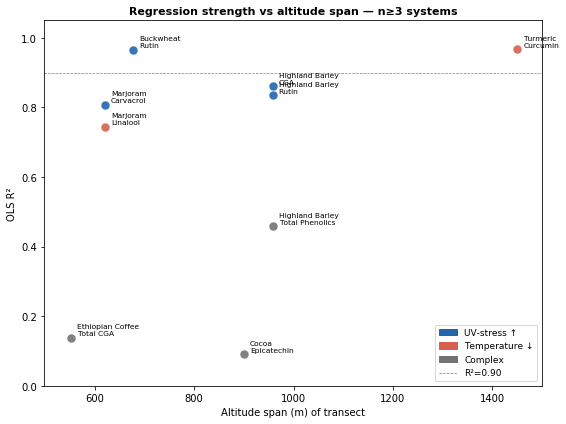

In [10]:
biplot_rows = []
for sys in SYSTEMS:
    alts, vals = system_data[sys['label']]
    n = len(alts)
    if n < 3:
        continue
    reg = ols(alts, vals)
    if reg is None:
        continue
    biplot_rows.append(dict(
        label=sys['label'].replace('\n', '\n'),
        alt_span=alts.max() - alts.min(),
        r2=reg['r2'],
        pval=reg['pval'],
        mechanism=sys['mechanism'],
        n=n
    ))

bp = pd.DataFrame(biplot_rows)

fig, ax = plt.subplots(figsize=(8, 6))
for _, row in bp.iterrows():
    ax.scatter(row['alt_span'], row['r2'],
               color=MECH_COLOR[row['mechanism']], s=80,
               alpha=0.9, edgecolors='white', linewidths=0.5, zorder=3)
    ax.annotate(row['label'], (row['alt_span'], row['r2']),
                textcoords='offset points', xytext=(6, 2), fontsize=7.5)

ax.set_xlabel('Altitude span (m) of transect', fontsize=10)
ax.set_ylabel('OLS R²', fontsize=10)
ax.set_ylim(0, 1.05)
ax.axhline(0.9, color='gray', lw=0.7, ls='--', label='R²=0.90')
ax.set_title('Regression strength vs altitude span — n≥3 systems', fontsize=11, fontweight='bold')

legend_patches = [mpatches.Patch(color=c, label=MECH_LABEL[m]) for m, c in MECH_COLOR.items()]
ax.legend(handles=legend_patches + [plt.Line2D([0],[0],color='gray',ls='--',lw=0.7,label='R²=0.90')],
          fontsize=9)

plt.tight_layout()
plt.savefig(OUT / 'altitude_r2_vs_span.png', dpi=150, bbox_inches='tight')
plt.show()

## Key findings

### UV-stress systems (blue panels — increases with altitude)
- **Carvacrol (marjoram, n=7, 766–1387m):** Strong non-linear increase; step-change at 1180m consistent with ecotype transition. UV-absorbing monoterpene phenol.
- **Rutin (buckwheat, n=3, 1422–2100m):** Monotonic increase. Rutin is a UV-screening flavonol — textbook UV-stress response.
- **CGA + rutin (highland barley, n=3, 2700–3658m):** CGA and rutin both increase at altitude. Variety confound (different varieties at each site) weakens causal inference but directional signal is consistent.
- **Andean blueberry TPC + TFC (n=2, 2836–3641m):** Consistent directional increase. n=2 insufficient for regression.
- **Purple corn anthocyanins + TPC (n=2, 2025–2828m):** Kernel anthocyanins +26% from 2025→2828m. UV-responsive pigments.
- **Brassica sulforaphane (n=2, 321–3340m):** Dramatic 2.15× increase over 3019m elevation. Glucosinolate-myrosinase product; known stress response.

### Temperature-driven systems (red panels — decreases with altitude)
- **Curcumin (turmeric, n=3, 80–1530m):** Monotonic decrease. Curcumin biosynthesis via PAL → HCT pathway is temperature-sensitive. Lowest temps at highest altitude suppress synthesis.
- **Linalool (marjoram, n=7, 766–1387m):** Inverse of carvacrol; linalool proportion decreases as carvacrol increases. These two terpenes compete in the same biosynthetic pathway.

### Complex / non-monotonic systems (gray panels)
- **Highland barley TPC (n=3):** COUNTERINTUITIVE — total phenolics highest at lowest altitude (429.77 mg GAE/100g at 2700m > 394.73 at 3658m). Driven by catechin + gallic acid loss at high altitude; UV-responsive CGA/rutin *do* increase but are numerically smaller. Variety confound may dominate.
- **Cocoa epicatechin (n=3):** Peaks at 400m (974 mg/100g) vs 100m (590) and 1000m (535). Soil Mn/N differences (Mihai 2022) explain more variance than altitude.
- **Ethiopian coffee CGA (n=5):** No altitude gradient across 1570–2123m. Variety × region co-variation dominates. Consistent with exclusion from within-crop regression.

### Cross-crop pattern
The UV-responsive compound classes (flavonols, hydroxycinnamic acids, anthocyanins, glucosinolates, phenolic terpenes) consistently increase with altitude across 6 independent crop systems and 4 continents. The temperature-driven pattern (curcumin, linalool) consistently decreases. This cross-crop convergence — despite completely different biosynthetic pathways — suggests a unified altitude metabolite constraint operating through shared environmental stressors (UV-B radiation, lower temperature).